In [2]:
import random
individual = [random.randint(0, 1) for _ in range(8)] + [int(i) for i in list(format(60, '08b'))] + [int(i) for i in list(format(60, '08b'))] + [int(i) for i in list(format(128, '08b'))]
print(individual)

print([int(i) for i in list(format(60, '08b'))] )

[1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 1, 1, 1, 1, 0, 0]


In [2]:
import os
import pandas as pd
def get_price_his():
    country = "us"
    stock_id = "NVDA"
    path_price_his = f"{os.path.abspath(os.getcwd())}/history_data/{country}/stock_price/{stock_id}tech.csv"
    # print(path_price_his)
    df_price_his = pd.read_csv(path_price_his, encoding="utf-8")
    df_price_his["Date"] = pd.to_datetime(df_price_his["Date"], format="%Y%m%d")
    return df_price_his

price_his = get_price_his()
price_his.head()

,Date,Volume,Open,High,Low,Close,MA5,MA10,MA20,EMA5,EMA12,EMA26,DIF,MACD,RSI,Volatility,K,D
0,2020-01-21,217917000,6.1951,6.2323,6.1643,6.1985,NaN,NaN,NaN,6.198500,6.198500,6.198500,0.000000,0.000000,NaN,NaN,50.000000,50.000000
1,2020-01-22,239238680,6.2440,6.3398,6.2250,6.2513,NaN,NaN,NaN,6.216100,6.206623,6.202411,0.004212,0.000842,NaN,NaN,49.857550,49.952517
2,2020-01-23,244514440,6.2930,6.3300,6.2038,6.3215,NaN,NaN,NaN,6.251233,6.224296,6.211233,0.013064,0.003287,NaN,NaN,63.095916,54.333650
3,2020-01-24,373513560,6.4375,6.4875,6.2075,6.2620,NaN,NaN,NaN,6.254822,6.230097,6.214993,0.015104,0.005650,NaN,NaN,52.140264,53.602521
4,2020-01-27,470534000,5.9560,6.0563,5.8057,6.0050,6.20766,NaN,NaN,6.171548,6.195467,6.199438,-0.003971,0.003726,NaN,NaN,44.503992,50.569678


# 高於EMA買進低於賣出

Best EMA days: 15


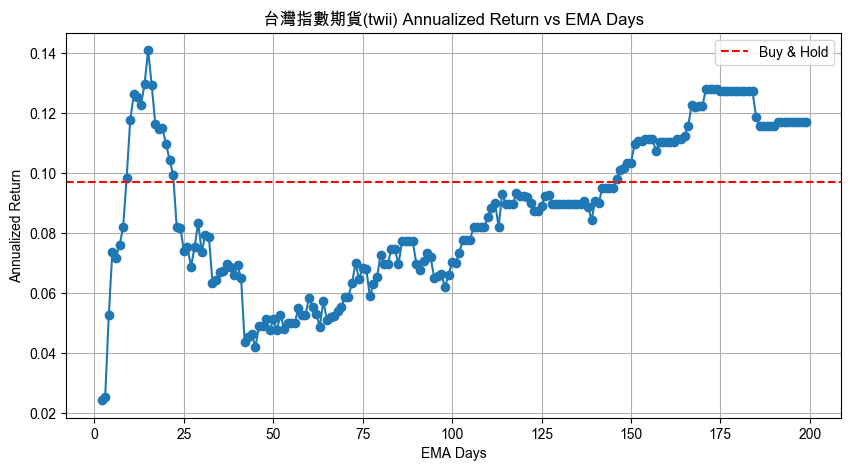

Best EMA days: 31


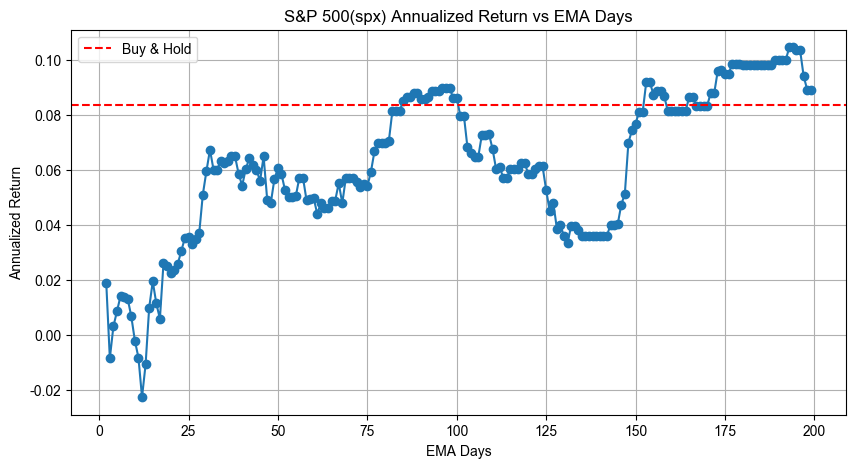

In [5]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties

font_path = '/Library/Fonts/Arial Unicode.ttf'  # 這是 macOS 上的一個中文字體
font_prop = FontProperties(fname=font_path)
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False  

def calculate_ema(data, span):
    return data.ewm(span=span, adjust=False).mean()

def get_price_his(stock_id, country):
    path_price_his = f"{os.path.abspath(os.getcwd())}/history_data/{country}/stock_price/{stock_id}tech.csv"
    df_price_his = pd.read_csv(path_price_his, encoding="utf-8")
    df_price_his["Date"] = pd.to_datetime(df_price_his["Date"], format="%Y%m%d")
    # 讓時間在 2023-01-01 之後
    df_price_his = df_price_his[df_price_his["Date"] >= "2022-01-01"]
    df_price_his = df_price_his[df_price_his["Date"] <= "2025-01-01"]
    
    return df_price_his

def run_ema(stock):
    stock_id = stock[0]
    stock_name = stock[1]
    country = stock[2]
    
    price_his = get_price_his(stock_id, country)
    # print(price_his.head())  # 顯示數據頭部

    ema_days = range(2, 200)
    annual_returns = []

    for i in ema_days:
        data = price_his.copy()
        data['Date'] = pd.to_datetime(data['Date'])  # 轉換日期格式
        data.set_index('Date', inplace=True)  # 設定日期為索引

        data['EMA'] = calculate_ema(data['Close'], span=i)  # 計算 i 日 EMA

        # 訊號判斷
        data['Signal'] = data['Close'].shift(1) > data['EMA'].shift(1)

        # 策略報酬
        data['Strategy_Return'] = data['Signal'].shift(1) * data['Open'].pct_change()

        # Buy & Hold 策略
        data['Buy_and_Hold'] = data['Close'].pct_change()

        # 計算累積報酬
        data['Cumulative_Strategy'] = (1 + data['Strategy_Return']).cumprod()
        data['Cumulative_Buy_Hold'] = (1 + data['Buy_and_Hold']).cumprod()

        # 計算年化報酬率
        days_per_year = 252
        buy_and_hold_return = price_his['Close'].pct_change().mean() * days_per_year

        annualized_return = data['Strategy_Return'].mean() * days_per_year
        annual_returns.append(annualized_return)

        # if i == 15:
        #     plt.figure(figsize=(15, 5))
        #     plt.plot(data.index, data['Close'], label='Close Price', linestyle='-')
        #     plt.plot(data.index, data['Cumulative_Strategy']*float(data['Close'].iloc[0]), label=f'EMA {i}', linestyle='-')

        #     # 繪製進出場訊號
        #     buy_signals = data[(data['Signal'].astype(bool)) & ~(data['Signal'].shift(1).astype(bool))]
        #     sell_signals = data[(~data['Signal'].astype(bool)) & (data['Signal'].shift(1).astype(bool))]

        #     plt.scatter(buy_signals.index, buy_signals['Close'], marker='^', color='g', label='Buy Signal', alpha=1, edgecolors='black')
        #     plt.scatter(sell_signals.index, sell_signals['Close'], marker='v', color='r', label='Sell Signal', alpha=1, edgecolors='black')

        #     plt.legend()
        #     plt.title(f'{stock_name}({stock_id}) Price and EMA with Buy/Sell Signals')
        #     plt.xlabel('Date')
        #     plt.ylabel('Price')
        #     plt.show()

    # print best index of annual return
    best_index = annual_returns.index(max(annual_returns[:50]))
    print(f"Best EMA days: {ema_days[best_index]}")
    
    # 繪製 EMA 日數與年化報酬率的關係圖
    plt.figure(figsize=(10, 5))
    plt.plot(ema_days, annual_returns, marker='o', linestyle='-')
    plt.axhline(y=buy_and_hold_return, color='r', linestyle='--', label='Buy & Hold')  # Buy & Hold 年化報酬率
    plt.title(f'{stock_name}({stock_id}) Annualized Return vs EMA Days')
    plt.xlabel('EMA Days')
    plt.ylabel('Annualized Return')
    plt.grid()
    plt.legend()
    plt.show()
    return annual_returns
    
stocks = [
    ["twii", "台灣指數期貨", "tw"],
    # ["2330", "台積電", "tw"],
    # ["2454", "聯發科", "tw"],
    # ["2317", "鴻海", "tw"],
    # ["2308", "台達電", "tw"],
    # ["2382", "廣達", "tw"],
    # ["2412", "中華電", "tw"],
    # ["2881", "富邦金", "tw"],
    # ["2882", "國泰金", "tw"],
    # ["2891", "中信金", "tw"],
    # ["6505", "台塑化", "tw"],
    
    # ["3231", "緯創", "tw"],
    # ["2207", "和泰車", "tw"],
    # ["3661", "世芯", "tw"],
    # ["2603", "長榮", "tw"],
    # ["2408", "南亞科", "tw"],
    
    ["spx", "S&P 500", "us"],
    # ["AAPL", "Apple Inc.", "us"],
    # ["MSFT", "Microsoft", "us"],
    # ["NVDA", "Nvidia", "us"],
    # ["AMZN", "Amazon inc.", "us"],
    # ["META", "Meta Platforms", "us"],
    # ["GOOGL", "Google", "us"],
    # ["TSLA", "Tesla", "us"],
    # ["AVGO", "Broadcom", "us"],
    # ["BRK", "Berkshire Hathaway", "us"],
    # ["JPM", "JPMorgan Chase", "us"],
    
    # ["BA", "Boeing", "us"],
    # ["MRNA", "Moderna", "us"],
    # ["WMT", "Walmart", "us"],
    # ["UNH", "UnitedHealth Group", "us"],
    # ["DIS", "Disney", "us"],
]

ema_rtns = []
for stock in stocks:
    stock_id = stock[0]
    stock_name = stock[1]
    country = stock[2]
    path_price_his = f"{os.path.abspath(os.getcwd())}/history_data/{country}/stock_price/{stock_id}tech.csv"
    if not os.path.exists(path_price_his):
        print(f"File not found: {path_price_his}")
        continue
    ema_rtn = run_ema(stock)
    ema_rtns.append(ema_rtn)

df_rtns = pd.DataFrame(ema_rtns, columns=range(2, 200), index=[stock[1] for stock in stocks])
    

# 低於EMA以下買進高於賣出

Best EMA days: 2


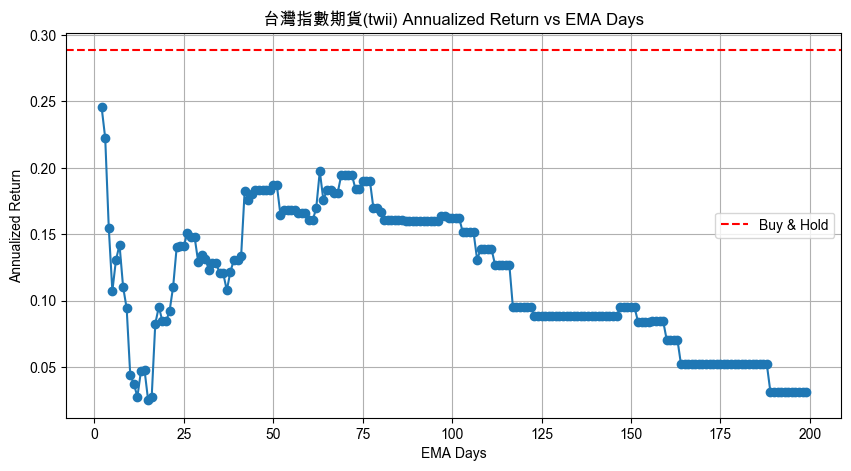

Best EMA days: 12


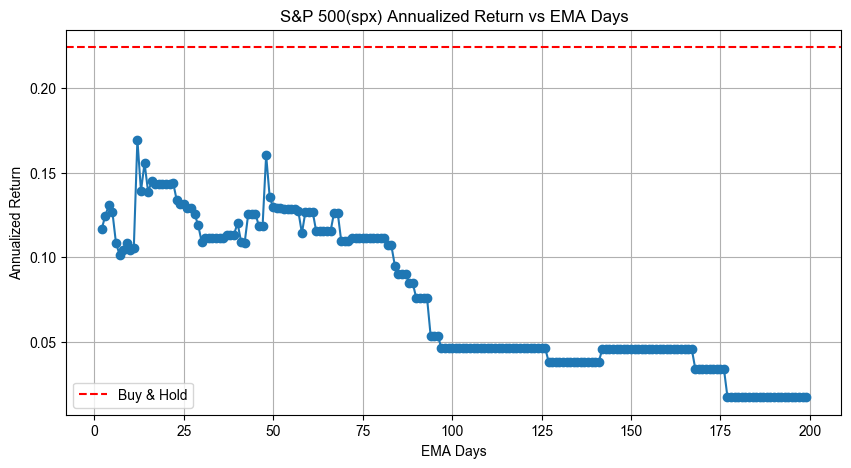

In [4]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties

font_path = '/Library/Fonts/Arial Unicode.ttf'  # 這是 macOS 上的一個中文字體
font_prop = FontProperties(fname=font_path)
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False  

def calculate_ema(data, span):
    return data.ewm(span=span, adjust=False).mean()

def get_price_his(stock_id, country):
    path_price_his = f"{os.path.abspath(os.getcwd())}/history_data/{country}/stock_price/{stock_id}tech.csv"
    df_price_his = pd.read_csv(path_price_his, encoding="utf-8")
    df_price_his["Date"] = pd.to_datetime(df_price_his["Date"], format="%Y%m%d")
    # 讓時間在 2023-01-01 之後
    df_price_his = df_price_his[df_price_his["Date"] >= "2024-01-01"]
    df_price_his = df_price_his[df_price_his["Date"] <= "2025-01-01"]
    
    return df_price_his

def run_ema(stock):
    stock_id = stock[0]
    stock_name = stock[1]
    country = stock[2]
    
    price_his = get_price_his(stock_id, country)
    # print(price_his.head())  # 顯示數據頭部

    ema_days = range(2, 200)
    annual_returns = []

    for i in ema_days:
        data = price_his.copy()
        data['Date'] = pd.to_datetime(data['Date'])  # 轉換日期格式
        data.set_index('Date', inplace=True)  # 設定日期為索引

        data['EMA'] = calculate_ema(data['Close'], span=i)  # 計算 i 日 EMA

        # 訊號判斷：低於 EMA 則買進，高於則賣出
        data['Signal'] = data['Close'].shift(1) < data['EMA'].shift(1)

        # 策略報酬
        data['Strategy_Return'] = data['Signal'].shift(1) * data['Open'].pct_change()

        # Buy & Hold 策略
        data['Buy_and_Hold'] = data['Close'].pct_change()

        # 計算累積報酬
        data['Cumulative_Strategy'] = (1 + data['Strategy_Return']).cumprod()
        data['Cumulative_Buy_Hold'] = (1 + data['Buy_and_Hold']).cumprod()

        # 計算年化報酬率
        days_per_year = 252
        buy_and_hold_return = price_his['Close'].pct_change().mean() * days_per_year

        annualized_return = data['Strategy_Return'].mean() * days_per_year
        annual_returns.append(annualized_return)

        # if i == 15:
        #     plt.figure(figsize=(15, 5))
        #     plt.plot(data.index, data['Close'], label='Close Price', linestyle='-')
        #     plt.plot(data.index, data['Cumulative_Strategy']*float(data['Close'].iloc[0]), label=f'EMA {i}', linestyle='-')
        #
        #     # 繪製進出場訊號
        #     buy_signals = data[(data['Signal'].astype(bool)) & ~(data['Signal'].shift(1).astype(bool))]
        #     sell_signals = data[(~data['Signal'].astype(bool)) & (data['Signal'].shift(1).astype(bool))]
        #
        #     plt.scatter(buy_signals.index, buy_signals['Close'], marker='^', color='g', label='Buy Signal', alpha=1, edgecolors='black')
        #     plt.scatter(sell_signals.index, sell_signals['Close'], marker='v', color='r', label='Sell Signal', alpha=1, edgecolors='black')
        #
        #     plt.legend()
        #     plt.title(f'{stock_name}({stock_id}) Price and EMA with Buy/Sell Signals')
        #     plt.xlabel('Date')
        #     plt.ylabel('Price')
        #     plt.show()

    # print best index of annual return
    best_index = annual_returns.index(max(annual_returns[:50]))
    print(f"Best EMA days: {ema_days[best_index]}")
    
    # 繪製 EMA 日數與年化報酬率的關係圖
    plt.figure(figsize=(10, 5))
    plt.plot(ema_days, annual_returns, marker='o', linestyle='-')
    plt.axhline(y=buy_and_hold_return, color='r', linestyle='--', label='Buy & Hold')  # Buy & Hold 年化報酬率
    plt.title(f'{stock_name}({stock_id}) Annualized Return vs EMA Days')
    plt.xlabel('EMA Days')
    plt.ylabel('Annualized Return')
    plt.grid()
    plt.legend()
    plt.show()
    return annual_returns
    
stocks = [
    ["twii", "台灣指數期貨", "tw"],
    # ["2330", "台積電", "tw"],
    # ["2454", "聯發科", "tw"],
    # ["2317", "鴻海", "tw"],
    # ["2308", "台達電", "tw"],
    # ["2382", "廣達", "tw"],
    # ["2412", "中華電", "tw"],
    # ["2881", "富邦金", "tw"],
    # ["2882", "國泰金", "tw"],
    # ["2891", "中信金", "tw"],
    # ["6505", "台塑化", "tw"],
    
    # ["3231", "緯創", "tw"],
    # ["2207", "和泰車", "tw"],
    # ["3661", "世芯", "tw"],
    # ["2603", "長榮", "tw"],
    # ["2408", "南亞科", "tw"],
    
    ["spx", "S&P 500", "us"],
    # ["AAPL", "Apple Inc.", "us"],
    # ["MSFT", "Microsoft", "us"],
    # ["NVDA", "Nvidia", "us"],
    # ["AMZN", "Amazon inc.", "us"],
    # ["META", "Meta Platforms", "us"],
    # ["GOOGL", "Google", "us"],
    # ["TSLA", "Tesla", "us"],
    # ["AVGO", "Broadcom", "us"],
    # ["BRK", "Berkshire Hathaway", "us"],
    # ["JPM", "JPMorgan Chase", "us"],
    
    # ["BA", "Boeing", "us"],
    # ["MRNA", "Moderna", "us"],
    # ["WMT", "Walmart", "us"],
    # ["UNH", "UnitedHealth Group", "us"],
    # ["DIS", "Disney", "us"],
]

ema_rtns = []
for stock in stocks:
    stock_id = stock[0]
    stock_name = stock[1]
    country = stock[2]
    path_price_his = f"{os.path.abspath(os.getcwd())}/history_data/{country}/stock_price/{stock_id}tech.csv"
    if not os.path.exists(path_price_his):
        print(f"File not found: {path_price_his}")
        continue
    ema_rtn = run_ema(stock)
    ema_rtns.append(ema_rtn)

df_rtns = pd.DataFrame(ema_rtns, columns=range(2, 200), index=[stock[1] for stock in stocks])
    